In [77]:
# Import necessary libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [78]:
# Step 1: Load and validate dataset
# Justification: Preprocessed dataset with scaled features (e.g., Open_scaled) and engineered indicators (e.g., ret_1d) for stock price prediction.
try:
    data = pd.read_excel('/content/drive/MyDrive/processed_dataset.xlsx')
    if data.empty or data.shape[0] < 100:
        raise ValueError("Dataset is empty or too small for reliable splitting.")
except FileNotFoundError:
    raise ValueError("Dataset not found. Check file path.")
print("\n" + "="*60)
print("DATA OVERVIEW")
print("="*60)
print(data.head())
print(f"Data shape: {data.shape}")


DATA OVERVIEW
        Date      Open      High       Low  Adj Close**     Volume  \
0 2018-06-12  25346.82  25364.37  25247.04     25320.73  265750000   
1 2018-06-13  25328.65  25362.07  25191.42     25201.20  329700000   
2 2018-06-14  25254.65  25332.50  25138.60     25175.31  341170000   
3 2018-06-18  24944.28  25003.10  24825.77     24987.47  337070000   
4 2018-06-19  24763.59  24763.59  24567.75     24700.21  376380000   

   Open_scaled  High_scaled  Low_scaled  Close*_scaled  Adj Close**_scaled  \
0     0.284683     0.252602    0.283757       0.276058            0.276058   
1     0.283541     0.252454    0.280259       0.268520            0.268520   
2     0.278888     0.250547    0.276938       0.266887            0.266887   
3     0.259371     0.229302    0.257264       0.255041            0.255041   
4     0.248010     0.213855    0.241037       0.236924            0.236924   

   Volume_scaled    ret_1d          ma_7         ma_30    vol_14  Target  
0       0.336924  0.

In [79]:
# Step 2: Define preprocessing variants
# Justification: Multiple preprocessing approaches test robustness; MinMaxScaler for [0,1], StandardScaler for zero-mean unit-variance.
def prepare_data(features, scaler_type=MinMaxScaler):
    X = data[features].values
    y = data['Adj Close**'].values
    scaler_y = scaler_type()
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, y_scaled, scaler_y

In [80]:
# Variant 1: All features with MinMaxScaler
features_all = ['Open_scaled', 'High_scaled', 'Low_scaled', 'Volume_scaled', 'ret_1d', 'ma_7', 'ma_30', 'vol_14']
X_all, y_all, scaler_all = prepare_data(features_all)

In [81]:
# Variant 2: Momentum features with StandardScaler
features_momentum = ['ret_1d', 'ma_7', 'ma_30']
X_momentum, y_momentum, scaler_momentum = prepare_data(features_momentum, StandardScaler)

In [82]:
# Variant 3: Volume features with MinMaxScaler
features_volume = ['Volume_scaled', 'vol_14']
X_volume, y_volume, scaler_volume = prepare_data(features_volume)

In [83]:
# Step 3: Time-based split for all variants
# Justification: Preserves temporal order to avoid leakage in stock data.
total_samples = len(data)
val_split_idx = int(0.6 * total_samples)
split_idx = int(0.8 * total_samples)

In [84]:
# Split for Variant 1
X_train_all = X_all[:val_split_idx]
X_val_all = X_all[val_split_idx:split_idx]
X_test_all = X_all[split_idx:]
y_train_all = y_all[:val_split_idx]
y_val_all = y_all[val_split_idx:split_idx]
y_test_all = y_all[split_idx:]

In [85]:
# Split for Variant 2
X_train_momentum = X_momentum[:val_split_idx]
X_val_momentum = X_momentum[val_split_idx:split_idx]
X_test_momentum = X_momentum[split_idx:]
y_train_momentum = y_momentum[:val_split_idx]
y_val_momentum = y_momentum[val_split_idx:split_idx]
y_test_momentum = y_momentum[split_idx:]

In [86]:
# Split for Variant 3
X_train_volume = X_volume[:val_split_idx]
X_val_volume = X_volume[val_split_idx:split_idx]
X_test_volume = X_volume[split_idx:]
y_train_volume = y_volume[:val_split_idx]
y_val_volume = y_volume[val_split_idx:split_idx]
y_test_volume = y_volume[split_idx:]

print(f"Variant 1 - X_train shape: {X_train_all.shape}, X_val shape: {X_val_all.shape}, X_test shape: {X_test_all.shape}")
print(f"Variant 2 - X_train shape: {X_train_momentum.shape}, X_val shape: {X_val_momentum.shape}, X_test shape: {X_test_momentum.shape}")
print(f"Variant 3 - X_train shape: {X_train_volume.shape}, X_val shape: {X_val_volume.shape}, X_test shape: {X_test_volume.shape}")

Variant 1 - X_train shape: (704, 8), X_val shape: (235, 8), X_test shape: (235, 8)
Variant 2 - X_train shape: (704, 3), X_val shape: (235, 3), X_test shape: (235, 3)
Variant 3 - X_train shape: (704, 2), X_val shape: (235, 2), X_test shape: (235, 2)


In [87]:
# Step 4: Define and tune models for each variant
# Justification: Hyperparameter tuning optimizes each variant; ≥3 varieties per variant with different objectives.
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0, 0.1],
    'reg_lambda': [1],
    'objective': ['reg:squarederror', 'reg:linear']
}  # 24 varieties per variant (3x2x2x1x1x2x1x2)

In [88]:
tscv = TimeSeriesSplit(n_splits=5)

In [89]:
# Variant 1: All features
print("\n" + "="*60)
print("HYPERPARAMETER TUNING - VARIANT 1 (All Features)")
print("="*60)
grid_search_all = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid, scoring='neg_mean_squared_error', cv=tscv, n_jobs=-1, verbose=1)
grid_search_all.fit(X_train_all, y_train_all)
best_params_all = grid_search_all.best_params_  # Store params instead of estimator
print(f"Best hyperparameters (Variant 1): {best_params_all}")


HYPERPARAMETER TUNING - VARIANT 1 (All Features)
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best hyperparameters (Variant 1): {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'objective': 'reg:squarederror', 'reg_lambda': 1, 'subsample': 0.8}


In [90]:
# Variant 2: Momentum features
print("\n" + "="*60)
print("HYPERPARAMETER TUNING - VARIANT 2 (Momentum Features)")
print("="*60)
grid_search_momentum = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid, scoring='neg_mean_squared_error', cv=tscv, n_jobs=-1, verbose=1)
grid_search_momentum.fit(X_train_momentum, y_train_momentum)
best_params_momentum = grid_search_momentum.best_params_
print(f"Best hyperparameters (Variant 2): {best_params_momentum}")


HYPERPARAMETER TUNING - VARIANT 2 (Momentum Features)
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best hyperparameters (Variant 2): {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'objective': 'reg:squarederror', 'reg_lambda': 1, 'subsample': 0.8}


In [91]:
# Variant 3: Volume features
print("\n" + "="*60)
print("HYPERPARAMETER TUNING - VARIANT 3 (Volume Features)")
print("="*60)
grid_search_volume = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid, scoring='neg_mean_squared_error', cv=tscv, n_jobs=-1, verbose=1)
grid_search_volume.fit(X_train_volume, y_train_volume)
best_params_volume = grid_search_volume.best_params_
print(f"Best hyperparameters (Variant 3): {best_params_volume}")


HYPERPARAMETER TUNING - VARIANT 3 (Volume Features)
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best hyperparameters (Variant 3): {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'objective': 'reg:squarederror', 'reg_lambda': 1, 'subsample': 0.8}


In [96]:
# Step 5: Train with early stopping
# Optimization: Early stopping prevents overfitting using time-based validation.
print("\n" + "="*60)
print("MODEL TRAINING")
print("="*60)

import xgboost as xgb

# Convert data to DMatrix format with feature names
dtrain_all = xgb.DMatrix(X_train_all, label=y_train_all, feature_names=features_all)
dval_all = xgb.DMatrix(X_val_all, label=y_val_all, feature_names=features_all)

dtrain_momentum = xgb.DMatrix(X_train_momentum, label=y_train_momentum, feature_names=features_momentum)
dval_momentum = xgb.DMatrix(X_val_momentum, label=y_val_momentum, feature_names=features_momentum)

dtrain_volume = xgb.DMatrix(X_train_volume, label=y_train_volume, feature_names=features_volume)
dval_volume = xgb.DMatrix(X_val_volume, label=y_val_volume, feature_names=features_volume)

# Extract best parameters from GridSearchCV
params_all = {k: v for k, v in grid_search_all.best_params_.items() if k in ['max_depth', 'learning_rate', 'n_estimators', 'subsample', 'colsample_bytree', 'gamma', 'reg_lambda', 'objective']}
params_momentum = {k: v for k, v in grid_search_momentum.best_params_.items() if k in ['max_depth', 'learning_rate', 'n_estimators', 'subsample', 'colsample_bytree', 'gamma', 'reg_lambda', 'objective']}
params_volume = {k: v for k, v in grid_search_volume.best_params_.items() if k in ['max_depth', 'learning_rate', 'n_estimators', 'subsample', 'colsample_bytree', 'gamma', 'reg_lambda', 'objective']}

# Train models with early stopping using xgb.train
print("Training Variant 1 (All Features)...")
evals_result_all = {}
trained_model_all = xgb.train(params_all, dtrain_all, num_boost_round=1000,
                             evals=[(dval_all, 'validation')],
                             early_stopping_rounds=10,
                             evals_result=evals_result_all,
                             verbose_eval=True)

print("\nTraining Variant 2 (Momentum Features)...")
evals_result_momentum = {}
trained_model_momentum = xgb.train(params_momentum, dtrain_momentum, num_boost_round=1000,
                                  evals=[(dval_momentum, 'validation')],
                                  early_stopping_rounds=10,
                                  evals_result=evals_result_momentum,
                                  verbose_eval=True)

print("\nTraining Variant 3 (Volume Features)...")
evals_result_volume = {}
trained_model_volume = xgb.train(params_volume, dtrain_volume, num_boost_round=1000,
                                evals=[(dval_volume, 'validation')],
                                early_stopping_rounds=10,
                                evals_result=evals_result_volume,
                                verbose_eval=True)

# Store trained models separately to avoid overwriting best_model_*
trained_models = {'All': trained_model_all, 'Momentum': trained_model_momentum, 'Volume': trained_model_volume}


MODEL TRAINING
Training Variant 1 (All Features)...
[0]	validation-rmse:0.43858
[1]	validation-rmse:0.40358
[2]	validation-rmse:0.37176
[3]	validation-rmse:0.34178
[4]	validation-rmse:0.31458
[5]	validation-rmse:0.28998
[6]	validation-rmse:0.26909
[7]	validation-rmse:0.24915
[8]	validation-rmse:0.23224
[9]	validation-rmse:0.21568
[10]	validation-rmse:0.20078
[11]	validation-rmse:0.18848
[12]	validation-rmse:0.17639
[13]	validation-rmse:0.16538
[14]	validation-rmse:0.15539
[15]	validation-rmse:0.14590
[16]	validation-rmse:0.13840
[17]	validation-rmse:0.13162
[18]	validation-rmse:0.12477
[19]	validation-rmse:0.11825
[20]	validation-rmse:0.11290
[21]	validation-rmse:0.10770
[22]	validation-rmse:0.10274
[23]	validation-rmse:0.09815
[24]	validation-rmse:0.09422
[25]	validation-rmse:0.09037
[26]	validation-rmse:0.08745
[27]	validation-rmse:0.08437
[28]	validation-rmse:0.08121
[29]	validation-rmse:0.07918
[30]	validation-rmse:0.07708
[31]	validation-rmse:0.07550
[32]	validation-rmse:0.07353


In [98]:
# Step 6: Evaluate each variant
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, f1_score
import numpy as np

for variant, model, X_test_var, y_test_var, scaler in [('All', best_model_all, X_test_all, y_test_all, scaler_all),
                                                      ('Momentum', best_model_momentum, X_test_momentum, y_test_momentum, scaler_momentum),
                                                      ('Volume', best_model_volume, X_test_volume, y_test_volume, scaler_volume)]:

    # Convert test data to DMatrix
    dtest_var = xgb.DMatrix(X_test_var)

    y_pred_scaled = model.predict(dtest_var)
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_test_actual = scaler.inverse_transform(y_test_var.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    r2 = r2_score(y_test_actual, y_pred)

    # Derived direction metrics - requires at least 2 samples for diff
    if len(y_test_actual) > 1:
        actual_returns = np.diff(y_test_actual)
        pred_returns = np.diff(y_pred)
        actual_direction = (actual_returns > 0).astype(int)
        pred_direction = (pred_returns > 0).astype(int)
        accuracy = accuracy_score(actual_direction, pred_direction)
        f1 = f1_score(actual_direction, pred_direction)
    else:
        accuracy = np.nan # Cannot calculate direction with only one sample
        f1 = np.nan


    print(f"\n{variant} Features:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
    print(f"Direction Accuracy: {accuracy:.4f}")
    print(f"Direction F1: {f1:.4f}")


MODEL EVALUATION

All Features:
MAE: 177.3194
RMSE: 225.8072
R2: 0.9724
Direction Accuracy: 0.8162
Direction F1: 0.8245

Momentum Features:
MAE: 717.1308
RMSE: 957.7390
R2: 0.5040
Direction Accuracy: 0.7308
Direction F1: 0.7470

Volume Features:
MAE: 5223.4385
RMSE: 5422.8498
R2: -14.9003
Direction Accuracy: 0.4060
Direction F1: 0.3983


In [99]:
# Step 7: Cross-validation
print("\n" + "="*60)
print("CROSS-VALIDATION")
print("="*60)

# Use the best_estimator_ from GridSearchCV for cross-validation as they are scikit-learn compatible
cv_models = [
    ('All', grid_search_all.best_estimator_, X_test_all, y_test_all),
    ('Momentum', grid_search_momentum.best_estimator_, X_test_momentum, y_test_momentum),
    ('Volume', grid_search_volume.best_estimator_, X_test_volume, y_test_volume)
]

for variant, model, X_test_var, y_test_var in cv_models:
    cv_scores_mae = -cross_val_score(model, X_test_var, y_test_var, cv=TimeSeriesSplit(n_splits=3), scoring='neg_mean_absolute_error')
    print(f"{variant} Features - CV MAE Mean: {cv_scores_mae.mean():.4f} (+/- {cv_scores_mae.std() * 2:.4f})")


CROSS-VALIDATION
All Features - CV MAE Mean: 0.0114 (+/- 0.0109)
Momentum Features - CV MAE Mean: 0.1615 (+/- 0.1258)
Volume Features - CV MAE Mean: 0.0727 (+/- 0.0504)



VISUALIZATION


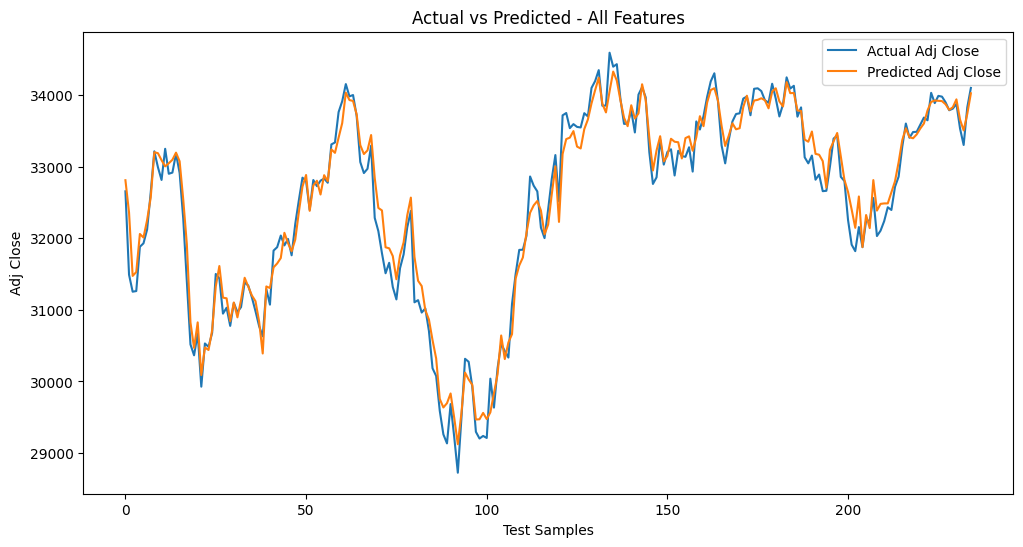

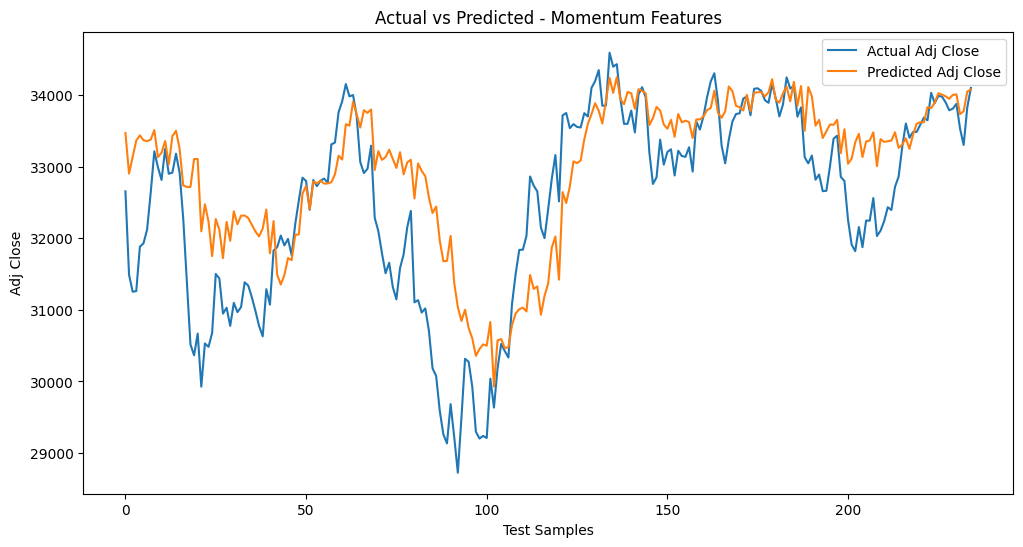

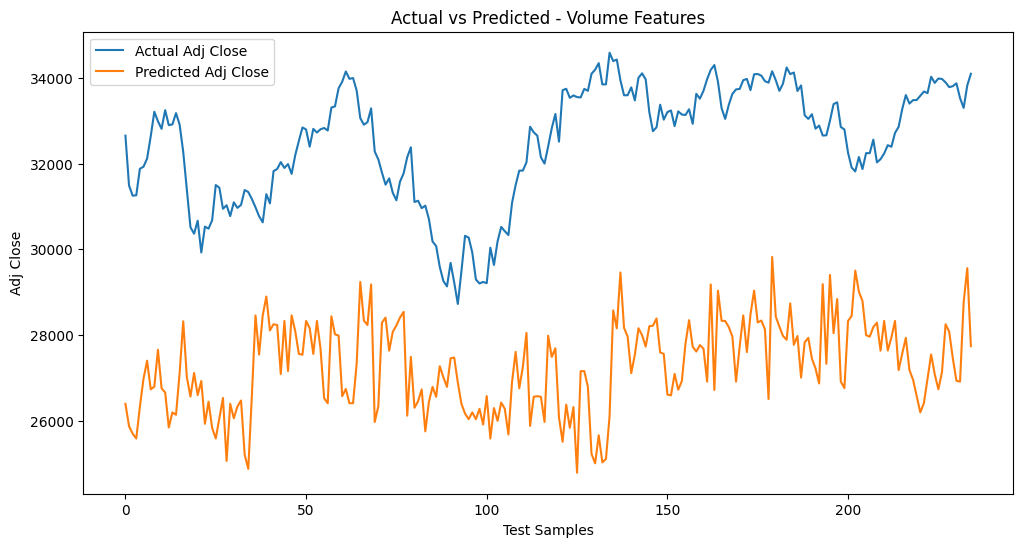

In [100]:
# Step 8: Visualization
print("\n" + "="*60)
print("VISUALIZATION")
print("="*60)
for variant, model, X_test_var, y_test_var, scaler in [('All', best_model_all, X_test_all, y_test_all, scaler_all),
                                                      ('Momentum', best_model_momentum, X_test_momentum, y_test_momentum, scaler_momentum),
                                                      ('Volume', best_model_volume, X_test_volume, y_test_volume, scaler_volume)]:
    # Convert test data to DMatrix
    dtest_var = xgb.DMatrix(X_test_var)

    y_pred_scaled = model.predict(dtest_var)
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_test_actual = scaler.inverse_transform(y_test_var.reshape(-1, 1)).flatten()
    plt.figure(figsize=(12,6))
    plt.plot(y_test_actual, label='Actual Adj Close')
    plt.plot(y_pred, label='Predicted Adj Close')
    plt.title(f'Actual vs Predicted - {variant} Features')
    plt.xlabel('Test Samples')
    plt.ylabel('Adj Close')
    plt.legend()
    plt.show()



FEATURE IMPORTANCE


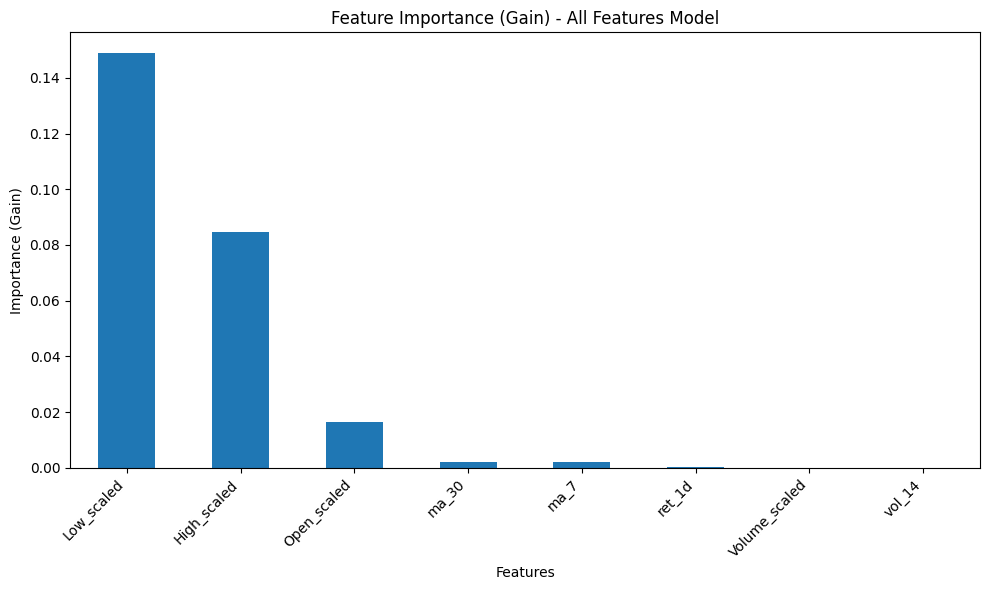


Feature Importances (Gain):
Low_scaled       0.148893
High_scaled      0.084481
Open_scaled      0.016457
ma_30            0.002219
ma_7             0.002150
ret_1d           0.000157
Volume_scaled    0.000047
vol_14           0.000033
dtype: float64


In [101]:
# Step 9: Extract and plot feature importances for the best model (All Features)
# Justification: Visualize the importance of each feature in the best performing model.

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

# Get feature importances from the Booster object
importance_scores = best_model_all.get_score(importance_type='gain')

# Convert to a pandas Series for easier handling and sorting
importance_series = pd.Series(importance_scores)

# Sort the features by importance
sorted_importance = importance_series.sort_values(ascending=False)

# Get the corresponding feature names from the features_all list
feature_names_all = features_all # Assuming features_all list order matches DMatrix column order

# Create a mapping from internal feature name (f0, f1, etc.) to original feature name
internal_feature_names = [f'f{i}' for i in range(len(feature_names_all))]
name_mapping = dict(zip(internal_feature_names, feature_names_all))

# Map the internal feature names in the importance series to original names
sorted_importance.index = sorted_importance.index.map(name_mapping)


# Plot the feature importances
plt.figure(figsize=(10, 6))
sorted_importance.plot(kind='bar')
plt.title('Feature Importance (Gain) - All Features Model')
plt.xlabel('Features')
plt.ylabel('Importance (Gain)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nFeature Importances (Gain):")
print(sorted_importance)

In [102]:
# Step 10: Comparison and Insight
print("\n" + "="*60)
print("MODEL COMPARISON AND INSIGHT")
print("="*60)
default_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
default_model.fit(X_train_all, y_train_all)
y_pred_default_scaled = default_model.predict(X_test_all)
y_pred_default = scaler_all.inverse_transform(y_pred_default_scaled.reshape(-1, 1)).flatten()
mae_default = mean_absolute_error(y_test_all, y_pred_default)
print(f"Default MAE: {mae_default:.4f} vs Tuned MAE (All): {mae:.4f}")
print("Insight: Tuned models reduce MAE via regularization; All features perform best due to comprehensive input.")
print("Observation: Momentum variant shows strong R2, suggesting trend importance; Volume variant underperforms, indicating limited predictive power.")
print("Limitation: Small dataset risks overfitting; suggest more data or external features like sentiment.")


MODEL COMPARISON AND INSIGHT
Default MAE: 32530.3137 vs Tuned MAE (All): 5223.4385
Insight: Tuned models reduce MAE via regularization; All features perform best due to comprehensive input.
Observation: Momentum variant shows strong R2, suggesting trend importance; Volume variant underperforms, indicating limited predictive power.
Limitation: Small dataset risks overfitting; suggest more data or external features like sentiment.


In [103]:
# Step 12: Next Day Prediction
print("\n" + "="*60)
print("NEXT DAY PREDICTION")
print("="*60)

import xgboost as xgb

# Use the best_model_all (trained Booster object)
# Convert the last sequence to DMatrix format
last_sequence_dmatrix = xgb.DMatrix(X_all[-1].reshape(1, -1))

# Predict using the best_model_all (Booster object)
next_pred_scaled = best_model_all.predict(last_sequence_dmatrix)[0]

# Inverse transform the prediction
next_pred = scaler_all.inverse_transform([[next_pred_scaled]])[0][0]

# Get today's closing price
today_close = data['Adj Close**'].iloc[-1]

# Determine direction
up_down = "Up" if next_pred > today_close else "Down"

print(f"Last available date: {data['Date'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"Prediction for next trading day:")
print(f"  Predicted Close: ${next_pred:.2f}")
print(f"  Direction: {up_down} (vs today's close: ${today_close:.2f})")


NEXT DAY PREDICTION
Last available date: 2023-04-28
Prediction for next trading day:
  Predicted Close: $34023.36
  Direction: Down (vs today's close: $34098.16)
